In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


import nvitk as nv
from nvitk import db

In [2]:
repo, xnat_config = db.get_repo_from_settings(return_xnat_config=True)

Using local root: ~/nvitk/dataset/nvitk-dataset


In [3]:
aux = repo.image(modality='4dflow', variables=['flow_mean'], wide=False)
aux = aux[(aux['variable_id' ] == 'flow_mean') & (aux['value_num'].notna())]

_SUBJECTS = pd.unique(aux.subject_uid)
_CLINICAL_VARS = ['age_at_mri', 'apoe_group', 'apoe', 'bmi', 'pp', 'map', 'hematocrit', 'pedframi10', 'pedframi30', 'sex', 'score2', 'tacsctot_group']
_PLAQUE_VARS = ['total_carotid_plaque_vol', 'total_femoral_plaque_vol', 'total_plaque_vol', 'right_carotid_plaque_vol', 'left_carotid_plaque_vol']
_COGNITIVE_VARS = ['z_compo_processingspeed', 'z_compo_globalfull', 'z_compo_epismemory', 'z_compo_attworkmemospeed']
_FLOW_VARS = ['flow_mean', 'pi']
_ASL_VARS = ['mean_cbf', 'att_mean']

TERRITORY_FLOW_REGIONS: dict[str, tuple[str, ...]] = {
    "ICA": ("left_ica", "right_ica"),
    "Venous": ("sagital_sinus", "straight_sinus", "left_transverse", "right_transverse"),
    "ACA": ( "left_aca", "right_aca"),
    "MCA": ("left_mca", "right_mca"),
    "PCA": ("left_pca", "right_pca"),
    "Basilar": ("basilar",),
}

TERRITORY_ASL_V8_REGIONS: dict[str, tuple[str, ...]] = {
    "ACA": (
        "left_aca_8",
        "right_aca_8",
    ),
    "MCA": (
        "left_mca_8",
        "right_mca_8",
    ),
    "PCA": (
        "left_pca_8",
        "right_pca_8",
    ),
    "Basilar": (
        "left_basilar_8",
        "right_basilar_8",
    ),
    "Watershed": ("watershed_0", "watershed_8"),
}

In [4]:
clinical  = repo.clinical(variables=_CLINICAL_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
plaque    = repo.clinical(variables=_PLAQUE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
cognitive = repo.cognitive(variables=_COGNITIVE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
clinical   = repo.join([clinical, plaque, cognitive])

flow      = repo.image(modality='4dflow', variables=_FLOW_VARS, filters={'subject_uid': {'$in': _SUBJECTS}}, pipeline='v1')
asl       = repo.image(modality='asl', variables=_ASL_VARS, atlas='vascular-8', filters={'subject_uid': {'$in': _SUBJECTS}})
image_df = repo.join([flow, asl])

territory_df = nv.stats.melt_imaging_territories(
    image_df, id_cols=['subject_uid'], 
    flow_vars=_FLOW_VARS, asl_vars=_ASL_VARS, 
    territory_flow_regions=TERRITORY_FLOW_REGIONS,
    territory_asl_v8_regions=TERRITORY_ASL_V8_REGIONS,
    include_frame_index=False
)

CACS

In [5]:
_IMAGING_VARS = ['mean_cbf']
_COVAR_FOR_MODEL = [
    "tacsctot_group",
    "age_at_mri",
    "sex",
    "hematocrit",
    # "score2",
]
_cov = [c for c in _COVAR_FOR_MODEL if c in clinical.columns]

analysis_df = nv.stats.build_analysis_df_from_repo_frames(
    territory_df,
    clinical,
    imaging_variable_ids=_IMAGING_VARS,
    covariate_cols=_cov,
)

analysis_df = analysis_df.dropna().reset_index(drop=True)
analysis_df["age_c"] = analysis_df["age_at_mri"] - float(analysis_df["age_at_mri"].mean())
analysis_df = analysis_df.drop(columns=['age_at_mri'])
analysis_df['territory'] = pd.Categorical(analysis_df['territory'], categories=list(TERRITORY_ASL_V8_REGIONS.keys()), ordered=True)
analysis_df['tacsctot_group'] = pd.Categorical(analysis_df['tacsctot_group'], categories=['g0', 'g1', 'g2', 'g3'], ordered=True)
analysis_df['mean_cbf'] = analysis_df['mean_cbf'].astype(np.float32)
analysis_df['hematocrit'] = analysis_df['hematocrit'].astype(np.float32)
analysis_df['age_c'] = analysis_df['age_c'].astype(np.float32)
analysis_df

,subject_uid,territory,mean_cbf,tacsctot_group,sex,hematocrit,age_c
0,PESA1006009,ACA,58.483761,g0,1,47.0,5.0718
1,PESA10061584,ACA,40.072781,g2,1,48.0,6.4718
2,PESA10067929,ACA,59.831661,g0,1,42.0,6.7418
3,PESA10086976,ACA,57.035610,g0,0,45.0,-4.6082
4,PESA10112400,ACA,56.868347,g0,1,48.0,-4.0582
...,...,...,...,...,...,...,...
1745,PESA9897316,Watershed,42.002037,g1,1,52.0,-2.4482
1746,PESA9928801,Watershed,49.882072,g0,0,45.0,4.3318
1747,PESA9935104,Watershed,46.629406,g0,0,45.0,2.7918
1748,PESA9947716,Watershed,55.293240,g1,1,42.0,1.3318


In [6]:
_STATSMODELS_BASE_DIR = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/nvitk-statmodels/')

In [7]:
formula = (
    f"mean_cbf ~ C(tacsctot_group, Treatment('g0')) "
    f"* C(territory, Treatment('MCA')) "
    f"+ age_c + sex + hematocrit"
)

_model_cols = [
    "mean_cbf",
    "tacsctot_group",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
]

res, df_fit, _meta = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / "cacs_mean_cbf" / "model.pkl",
    data=analysis_df,
    formula=formula,
    groups="territory",
    re_formula="0",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res,
    outcome_name="mean_cbf",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / "cacs_mean_cbf" / "info.txt",
)


Mixed Linear Model - mean_cbf
Formula: mean_cbf ~ C(tacsctot_group, Treatment('g0')) * C(territory, Treatment('MCA')) + age_c + sex + hematocrit
Observations: 1,750
territory groups: 5

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                             100.8193      0.8020           0       ***
C(tacsctot_group, Treatment('g0'))[T.g1]      1.6285      0.9737     0.09442         .
C(tacsctot_group, Treatment('g0'))[T.g2]      1.0937      1.5507      0.4806        NS
C(tacsctot_group, Treatment('g0'))[T.g3]     -1.6890      1.7121      0.3239        NS
C(territory, Treatment('MCA'))[T.ACA]     -0.2741      0.7615      0.7188        NS
C(territory, Treatment('MCA'))[T.PCA]     -5.0405      0.7578   2.897e-11       ***
C(territory, Treatment('MCA'))[T.Basilar]     -4.3508      0.7612   1.093e-08       ***
C(territory, Treatment('MCA'))[T

"========================================================================================\nMixed Linear Model - mean_cbf\n========================================================================================\nFormula: mean_cbf ~ C(tacsctot_group, Treatment('g0')) * C(territory, Treatment('MCA')) + age_c + sex + hematocrit\nObservations: 1,750\nterritory groups: 5\n\nFixed effects\n----------------------------------------------------------------------------------------\nParameter                                 Coef     Std.Err     P-value       Sig\nIntercept                             100.8193      0.8020           0       ***\nC(tacsctot_group, Treatment('g0'))[T.g1]      1.6285      0.9737     0.09442         .\nC(tacsctot_group, Treatment('g0'))[T.g2]      1.0937      1.5507      0.4806        NS\nC(tacsctot_group, Treatment('g0'))[T.g3]     -1.6890      1.7121      0.3239        NS\nC(territory, Treatment('MCA'))[T.ACA]     -0.2741      0.7615      0.7188        NS\nC(territor

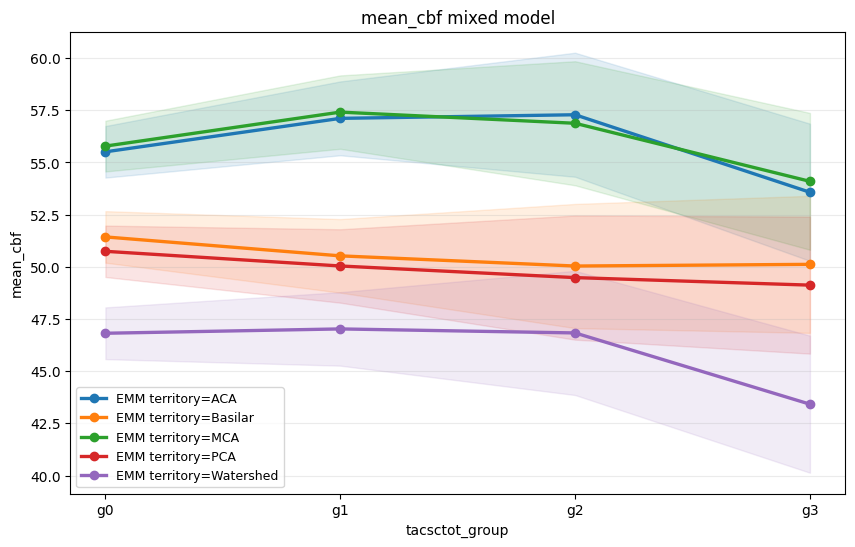

In [8]:
fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="tacsctot_group",
    y="mean_cbf",
    group="territory",
    errorbar=True,
    categorical_order=["g0", "g1", "g2", "g3"],
    mode="categorical",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / "cacs_mean_cbf" / "plot.png",
    title="mean_cbf mixed model",
    x_label="tacsctot_group",
    y_label="mean_cbf",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean()), "age_c": float(df_fit["age_c"].mean())},
)


pi age

In [9]:
_IMAGING_VARS = ['pi']
_COVAR_FOR_MODEL = [
    "tacsctot_group",
    "age_at_mri",
    "sex",
    "hematocrit",
    # "score2",
]
_cov = [c for c in _COVAR_FOR_MODEL if c in clinical.columns]

ONE2ONE_FLOW_REGIONS = {
    "LICA": ("left_ica",),
    "RICA": ("right_ica",),
    "SSSV": ("sagital_sinus",),
    "STRV": ("straight_sinus",),
    "LTSV": ("left_transverse",),
    "RTSV": ("right_transverse",),
    "LACA": ("left_aca",),
    "RACA": ("right_aca",),
    "LMCA": ("left_mca",),
    "RMCA": ("right_mca",),
    "LPCA": ("left_pca",),
    "RPCA": ("right_pca",),
    "Basi": ("basilar",),
}

TERRITORY_FLOW_REGIONS: dict[str, tuple[str, ...]] = {
    "ICA": ("left_ica", "right_ica"),
    "Venous": ("sagital_sinus", "straight_sinus", "left_transverse", "right_transverse"),
    "ACA": ( "left_aca", "right_aca"),
    "MCA": ("left_mca", "right_mca"),
    "PCA": ("left_pca", "right_pca"),
    "Basilar": ("basilar",),
}
territory_df = nv.stats.melt_imaging_territories(
    image_df, id_cols=['subject_uid'], 
    flow_vars=_IMAGING_VARS, 
    territory_flow_regions=TERRITORY_FLOW_REGIONS,
    include_frame_index=False
)

analysis_df = nv.stats.build_analysis_df_from_repo_frames(
    territory_df,
    clinical,
    imaging_variable_ids=_IMAGING_VARS,
    covariate_cols=_cov,
)

analysis_df = analysis_df.dropna().reset_index(drop=True)
analysis_df["age_c"] = analysis_df["age_at_mri"] - float(analysis_df["age_at_mri"].mean())
analysis_df = analysis_df.drop(columns=['age_at_mri'])
analysis_df = analysis_df[(analysis_df['territory'] != 'Unmapped') & (analysis_df['territory'] != 'Communicating') & (~analysis_df['territory'].isnull())]
analysis_df['territory'] = pd.Categorical(analysis_df['territory'], categories=list(TERRITORY_FLOW_REGIONS.keys()), ordered=True)
analysis_df['tacsctot_group'] = pd.Categorical(analysis_df['tacsctot_group'], categories=['g0', 'g1', 'g2', 'g3'], ordered=True)
analysis_df['pi'] = analysis_df['pi'].astype(np.float32)
analysis_df['hematocrit'] = analysis_df['hematocrit'].astype(np.float32)
analysis_df['age_c'] = analysis_df['age_c'].astype(np.float32)
analysis_df

,subject_uid,territory,pi,tacsctot_group,sex,hematocrit,age_c
0,PESA1006009,Basilar,0.791092,g0,1,47.0,5.096115
1,PESA10061584,Basilar,0.819871,g2,1,48.0,6.496115
2,PESA10067929,Basilar,0.810012,g0,1,42.0,6.766115
3,PESA10086976,Basilar,0.657827,g0,0,45.0,-4.583885
4,PESA10112400,Basilar,0.657464,g0,1,48.0,-4.033885
...,...,...,...,...,...,...,...
2250,PESA9897316,Venous,0.278454,g1,1,52.0,-2.423885
2251,PESA9928801,Venous,1.066115,g0,0,45.0,4.356115
2252,PESA9935104,Venous,0.394184,g0,0,45.0,2.816115
2253,PESA9947716,Venous,0.407565,g1,1,42.0,1.356115


In [ ]:
formula = (
    f"pi ~ age_c + sex + hematocrit"
)

_model_cols = [
    "pi",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
]

res, df_fit, _meta = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / "age_pi" / "model.pkl",
    data=analysis_df,
    formula=formula,
    groups="territory",
    re_formula="1 + age_c",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res,
    outcome_name="pi",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / "age_pi" / "info.txt",
)


/tmp/ipykernel_1037950/1602453471.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


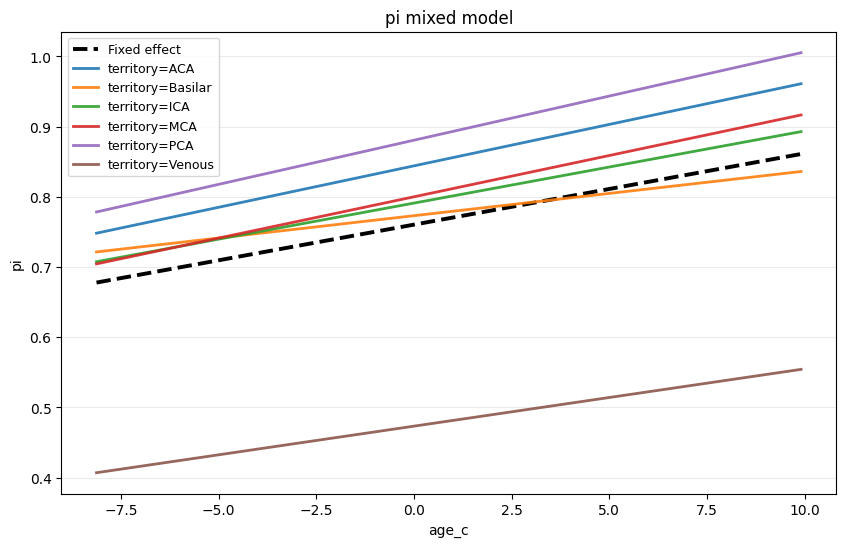

In [ ]:
fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="age_c",
    y="pi",
    group="territory",
    mode="auto",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / "age_pi" / "plot.png",
    title="pi mixed model",
    x_label="age_c",
    y_label="pi",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean())},
)
fig.show()